# Exploratory Data Analysis — Epileptic Seizure Recognition
**Dataset:** UCI Epileptic Seizure Recognition (Kaggle)  
**Samples:** 11,500 | **Features:** 178 EEG time-steps | **Classes:** 5

## 1. Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

CLASS_NAMES = {
    1: 'Seizure',
    2: 'Tumour Area',
    3: 'Healthy Area',
    4: 'Eyes Closed',
    5: 'Eyes Open'
}
CLASS_COLORS = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12', '#9b59b6']
print('Libraries loaded.')

Libraries loaded.


## 2. Load Dataset

In [2]:
df = pd.read_csv('data/Epileptic Seizure Recognition.csv')
print('Shape:', df.shape)
df.head(3)

Shape: (11500, 180)


,Unnamed,X1,X2,X3,X4,X5,X6,X7,X8,X9,...,X170,X171,X172,X173,X174,X175,X176,X177,X178,y
0,X21.V1.791,135,190,229,223,192,125,55,-9,-33,...,-17,-15,-31,-77,-103,-127,-116,-83,-51,4
1,X15.V1.924,386,382,356,331,320,315,307,272,244,...,164,150,146,152,157,156,154,143,129,1
2,X8.V1.1,-32,-39,-47,-37,-32,-36,-57,-73,-85,...,57,64,48,19,-12,-30,-35,-35,-36,5


In [3]:
print('=== Dataset Overview ===')
print(f'Total Samples  : {df.shape[0]}')
print(f'Total Columns  : {df.shape[1]}')
print(f'EEG Features   : 178  (X1 – X178)')
print(f'Missing Values : {df.isnull().sum().sum()}')
print(f'Duplicate Rows : {df.duplicated().sum()}')
print(f'Data Types     : {df.dtypes.value_counts().to_dict()}')

=== Dataset Overview ===
Total Samples  : 11500
Total Columns  : 180
EEG Features   : 178  (X1 – X178)
Missing Values : 0
Duplicate Rows : 0
Data Types     : {dtype('int64'): 179, <StringDtype(storage='python', na_value=nan)>: 1}


## 3. Class Distribution

In [4]:
print('Class Distribution:')
for cls, count in df['y'].value_counts().sort_index().items():
    print(f'  Class {cls} ({CLASS_NAMES[cls]:15s}): {count} samples ({count/len(df)*100:.1f}%)')

Class Distribution:
  Class 1 (Seizure        ): 2300 samples (20.0%)
  Class 2 (Tumour Area    ): 2300 samples (20.0%)
  Class 3 (Healthy Area   ): 2300 samples (20.0%)
  Class 4 (Eyes Closed    ): 2300 samples (20.0%)
  Class 5 (Eyes Open      ): 2300 samples (20.0%)


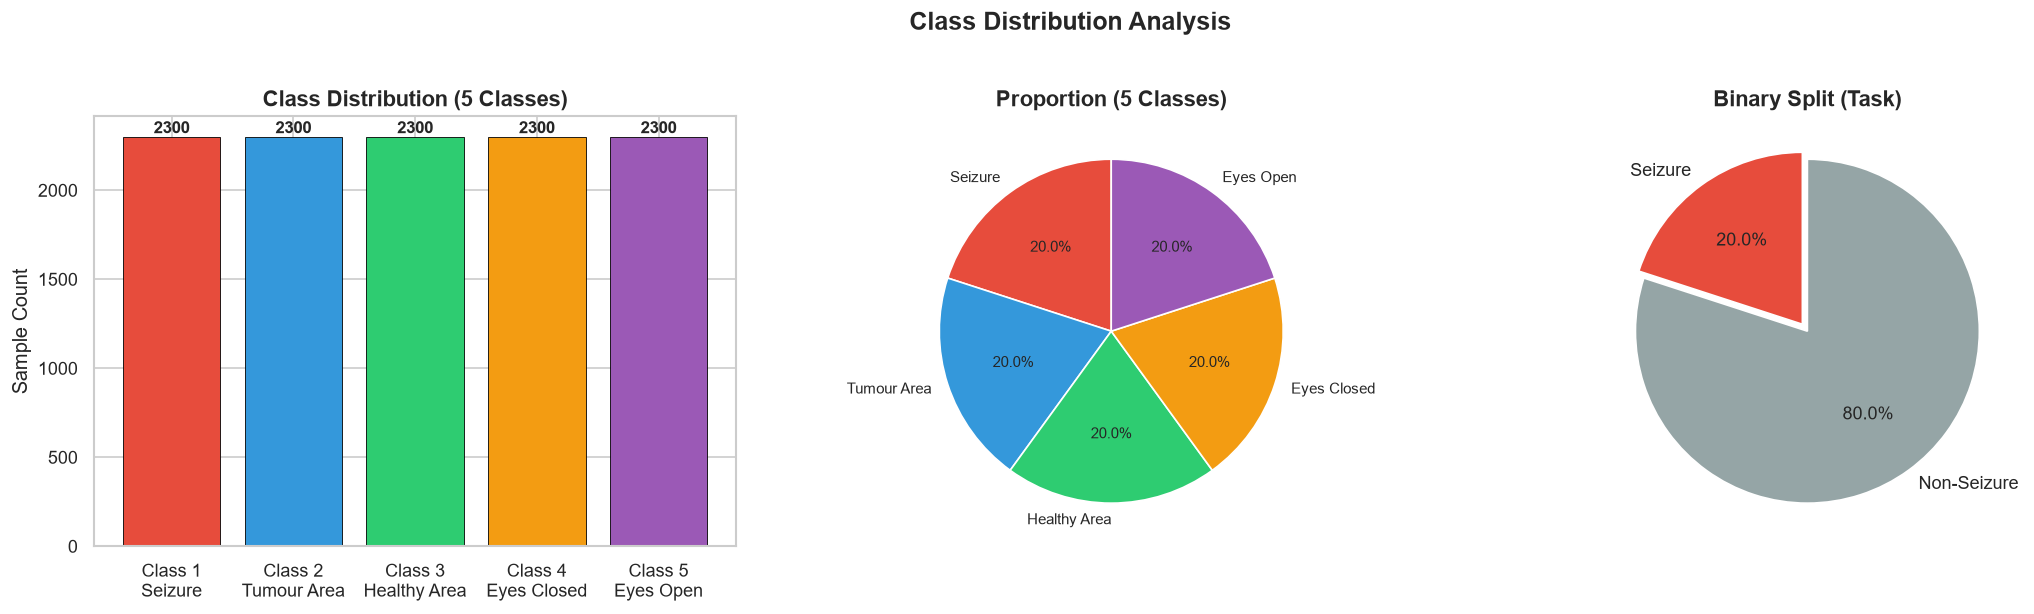

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Bar chart — 5 classes
counts = df['y'].value_counts().sort_index()
labels = [f'Class {i}\n{CLASS_NAMES[i]}' for i in counts.index]
bars = axes[0].bar(labels, counts.values, color=CLASS_COLORS, edgecolor='black', linewidth=0.5)
axes[0].set_title('Class Distribution (5 Classes)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Sample Count')
for bar, v in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
                 str(v), ha='center', fontweight='bold', fontsize=10)

# Pie chart — 5 classes
axes[1].pie(counts.values, labels=[CLASS_NAMES[i] for i in counts.index],
            colors=CLASS_COLORS, autopct='%1.1f%%', startangle=90,
            textprops={'fontsize': 9})
axes[1].set_title('Proportion (5 Classes)', fontsize=13, fontweight='bold')

# Pie chart — binary
binary = [(df['y'] == 1).sum(), (df['y'] != 1).sum()]
axes[2].pie(binary, labels=['Seizure', 'Non-Seizure'],
            colors=['#e74c3c', '#95a5a6'], autopct='%1.1f%%', startangle=90,
            explode=(0.05, 0), textprops={'fontsize': 11})
axes[2].set_title('Binary Split (Task)', fontsize=13, fontweight='bold')

plt.suptitle('Class Distribution Analysis', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('outputs/eda_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. EEG Signal Visualization Per Class

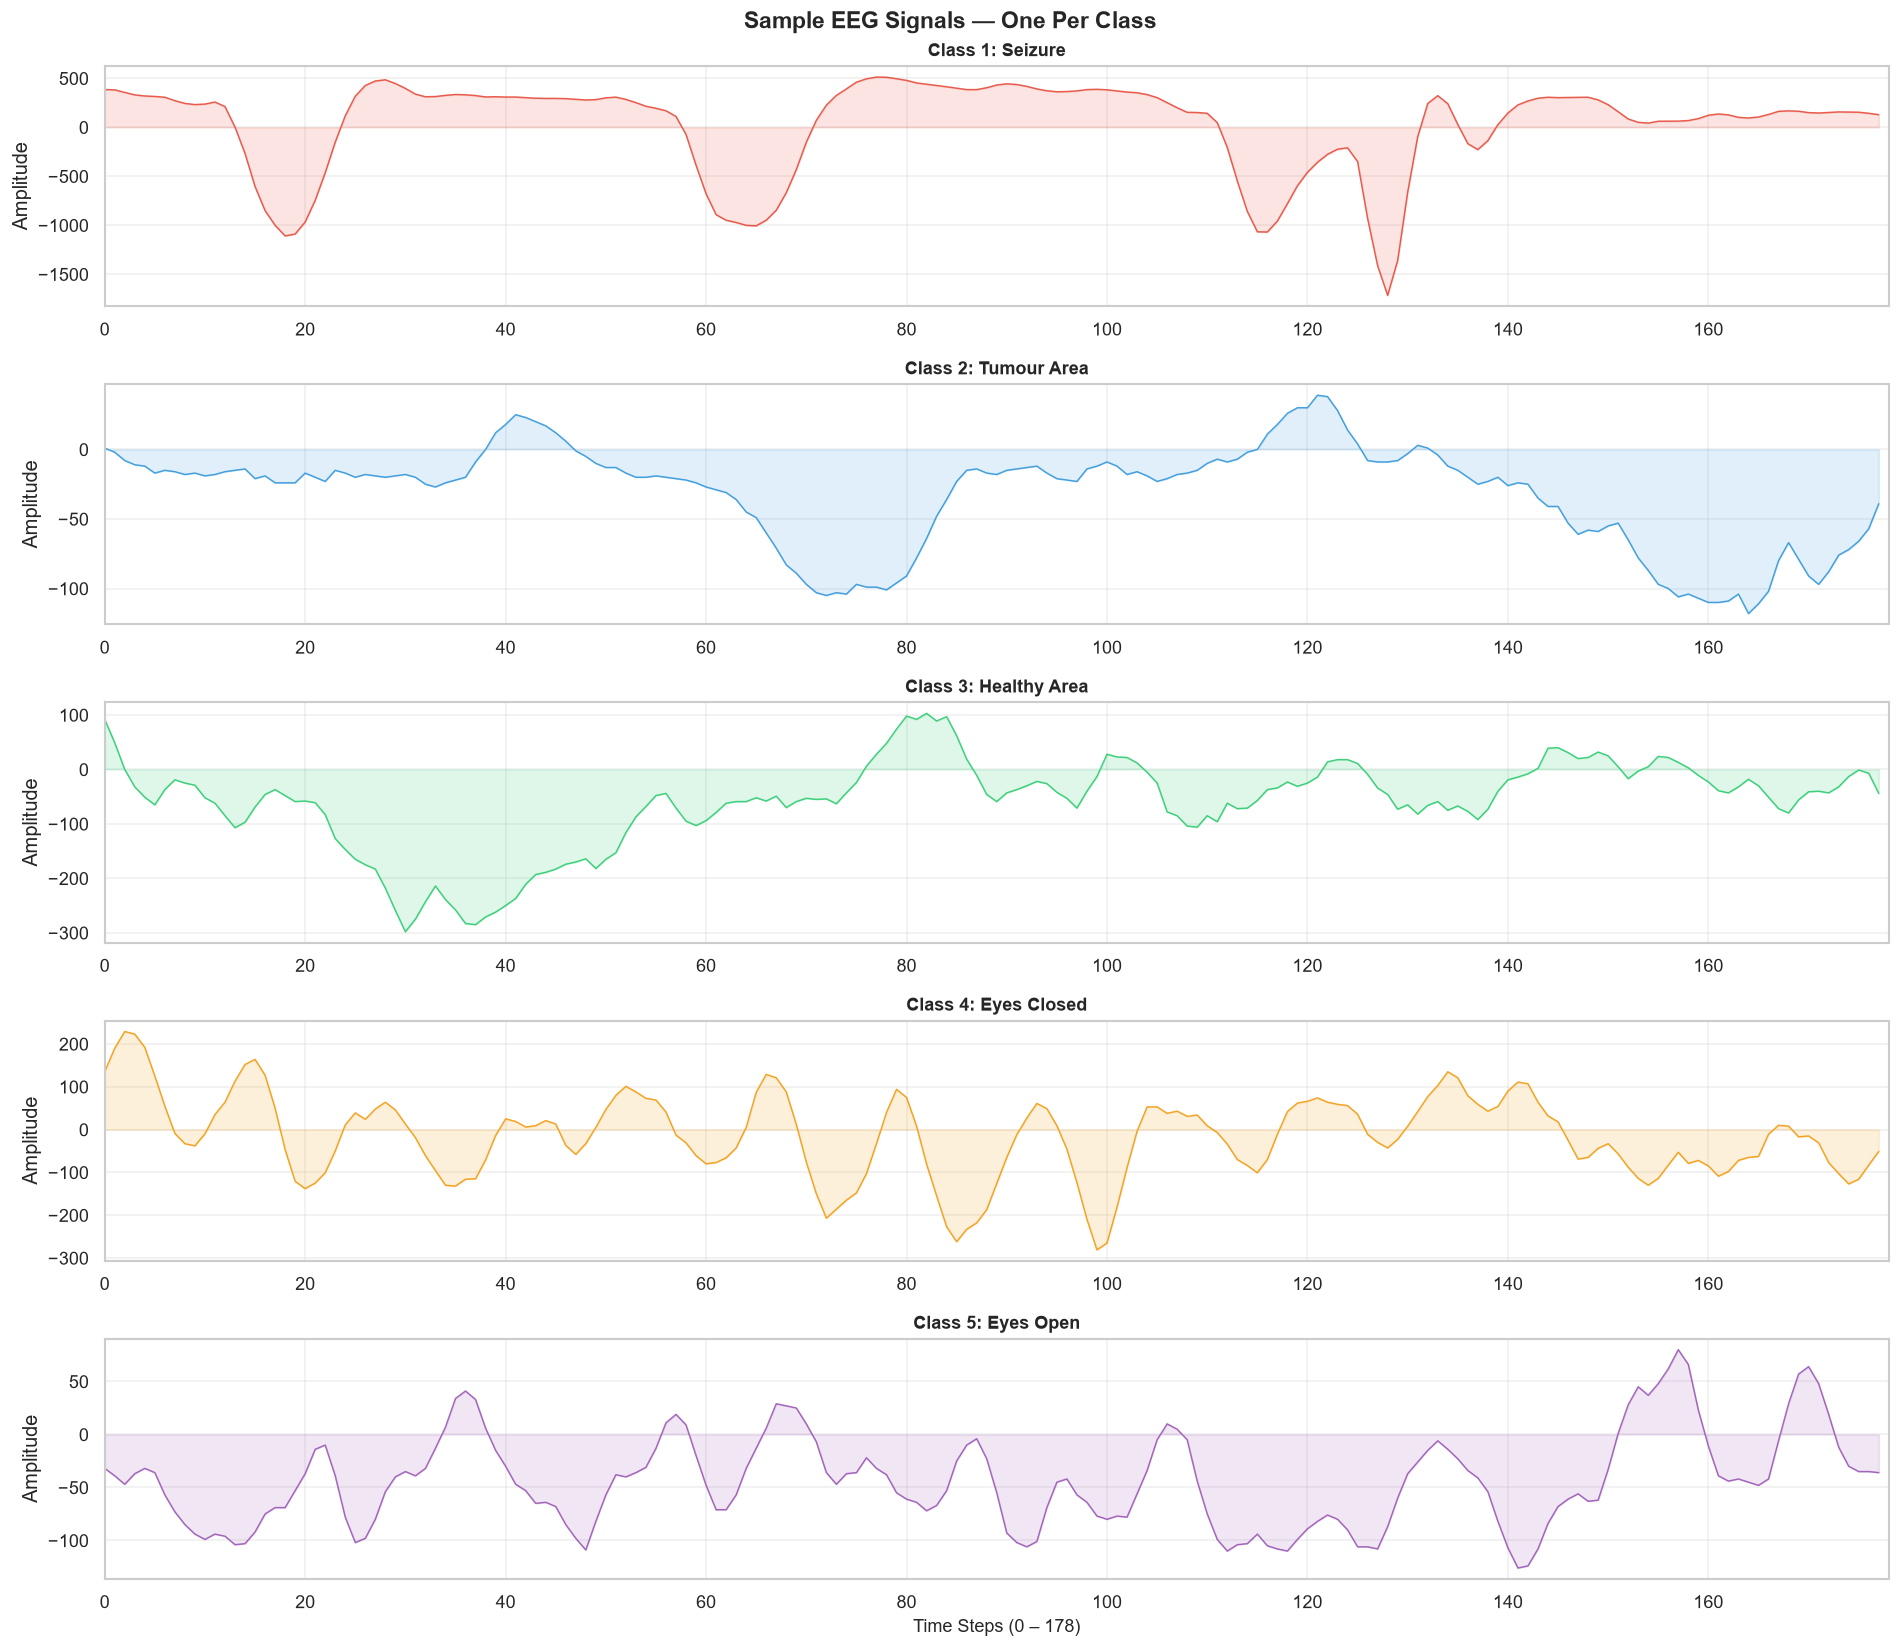

In [6]:
feature_cols = [c for c in df.columns if c.startswith('X')]

fig, axes = plt.subplots(5, 1, figsize=(16, 14))
for i, (cls, color) in enumerate(zip(range(1, 6), CLASS_COLORS)):
    sample = df[df['y'] == cls][feature_cols].iloc[0].values
    axes[i].plot(sample, color=color, linewidth=0.9, alpha=0.9)
    axes[i].fill_between(range(len(sample)), sample, alpha=0.15, color=color)
    axes[i].set_title(f'Class {cls}: {CLASS_NAMES[cls]}', fontsize=11, fontweight='bold')
    axes[i].set_ylabel('Amplitude')
    axes[i].grid(alpha=0.3)
    axes[i].set_xlim([0, 178])

axes[-1].set_xlabel('Time Steps (0 – 178)', fontsize=11)
plt.suptitle('Sample EEG Signals — One Per Class', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/eda_eeg_signals.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Statistical Summary Per Class

In [7]:
stats = []
for cls in range(1, 6):
    subset = df[df['y'] == cls][feature_cols].values.flatten()
    stats.append({
        'Class': f'Class {cls} — {CLASS_NAMES[cls]}',
        'Mean':  round(subset.mean(), 2),
        'Std':   round(subset.std(), 2),
        'Min':   round(subset.min(), 2),
        'Max':   round(subset.max(), 2),
        'Range': round(subset.max() - subset.min(), 2)
    })

stats_df = pd.DataFrame(stats).set_index('Class')
print('Statistical Summary Per Class:')
stats_df

Statistical Summary Per Class:


,Mean,Std,Min,Max,Range
Class,,,,,
Class 1 — Seizure,-4.76,341.15,-1885,2047,3932
Class 2 — Tumour Area,-6.20,90.35,-1147,2047,3194
Class 3 — Healthy Area,-8.88,59.39,-412,623,1035
Class 4 — Eyes Closed,-12.51,70.69,-424,360,784
Class 5 — Eyes Open,-6.26,48.34,-288,294,582


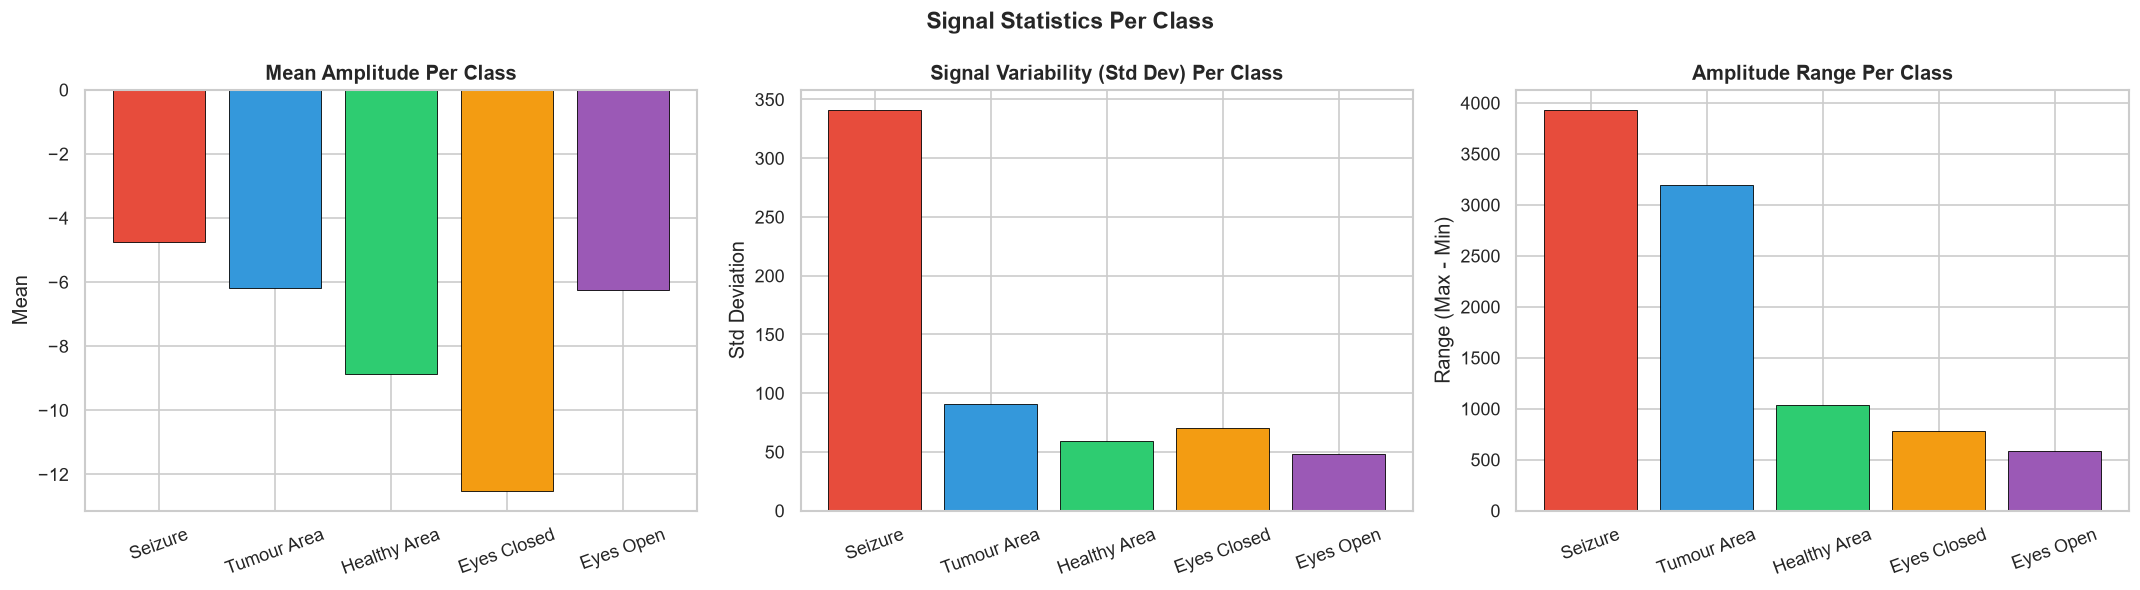

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
class_labels_short = [CLASS_NAMES[i] for i in range(1, 6)]

# Mean amplitude
means = [stats[i]['Mean'] for i in range(5)]
axes[0].bar(class_labels_short, means, color=CLASS_COLORS, edgecolor='black', lw=0.5)
axes[0].set_title('Mean Amplitude Per Class', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Mean')
axes[0].tick_params(axis='x', rotation=20)

# Std deviation
stds = [stats[i]['Std'] for i in range(5)]
axes[1].bar(class_labels_short, stds, color=CLASS_COLORS, edgecolor='black', lw=0.5)
axes[1].set_title('Signal Variability (Std Dev) Per Class', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Std Deviation')
axes[1].tick_params(axis='x', rotation=20)

# Amplitude range
ranges = [stats[i]['Range'] for i in range(5)]
axes[2].bar(class_labels_short, ranges, color=CLASS_COLORS, edgecolor='black', lw=0.5)
axes[2].set_title('Amplitude Range Per Class', fontsize=12, fontweight='bold')
axes[2].set_ylabel('Range (Max - Min)')
axes[2].tick_params(axis='x', rotation=20)

plt.suptitle('Signal Statistics Per Class', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/eda_signal_stats.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Amplitude Distribution Per Class

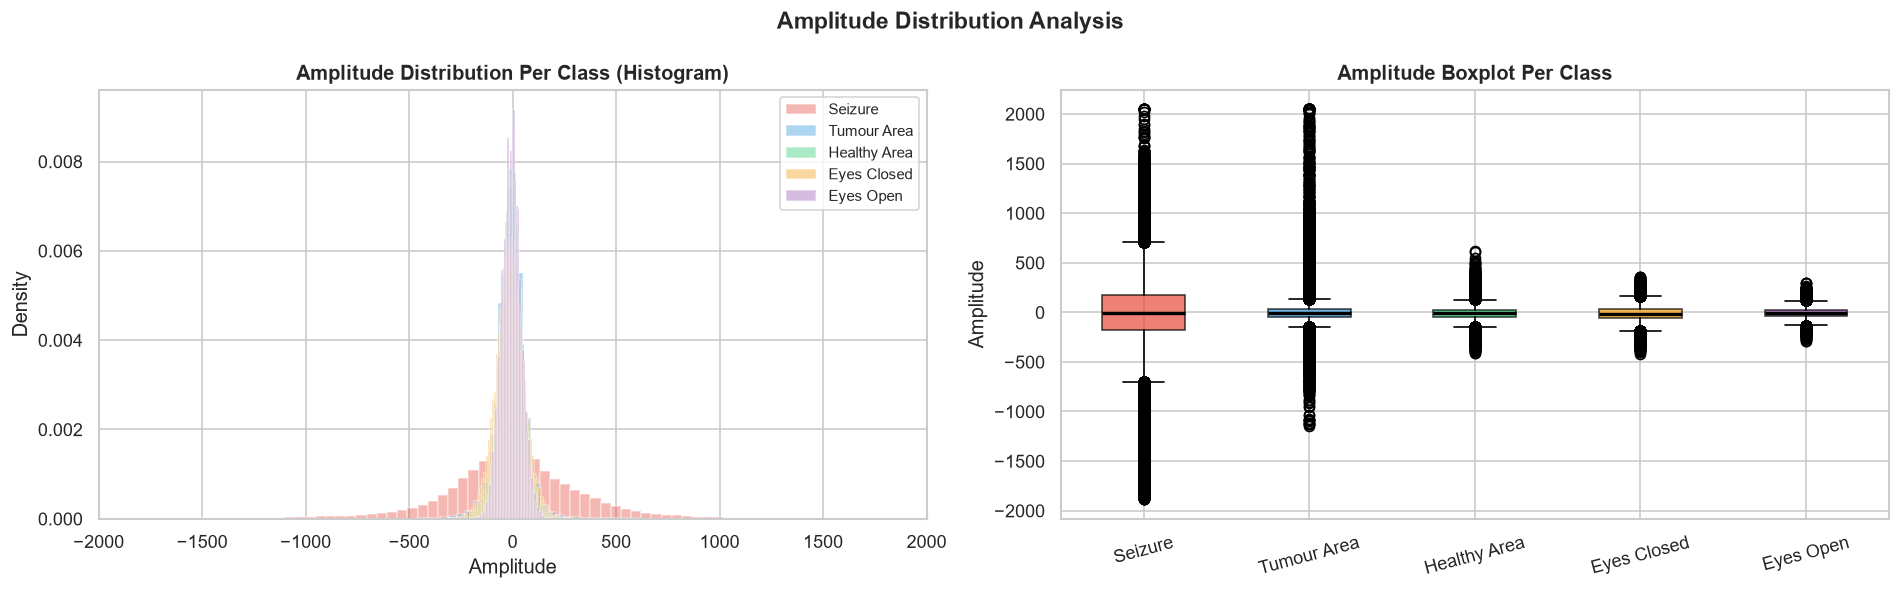

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# KDE plot
for cls, color in zip(range(1, 6), CLASS_COLORS):
    vals = df[df['y'] == cls][feature_cols].values.flatten()
    axes[0].hist(vals, bins=80, alpha=0.4, color=color,
                 label=CLASS_NAMES[cls], density=True)
axes[0].set_title('Amplitude Distribution Per Class (Histogram)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Amplitude'); axes[0].set_ylabel('Density')
axes[0].legend(fontsize=9); axes[0].set_xlim([-2000, 2000])

# Boxplot
box_data = [df[df['y'] == cls][feature_cols].values.flatten() for cls in range(1, 6)]
bp = axes[1].boxplot(box_data, patch_artist=True, notch=False,
                      medianprops=dict(color='black', linewidth=2))
for patch, color in zip(bp['boxes'], CLASS_COLORS):
    patch.set_facecolor(color); patch.set_alpha(0.7)
axes[1].set_xticklabels([CLASS_NAMES[i] for i in range(1, 6)], rotation=15)
axes[1].set_title('Amplitude Boxplot Per Class', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Amplitude')

plt.suptitle('Amplitude Distribution Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/eda_amplitude_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Feature Variance Analysis

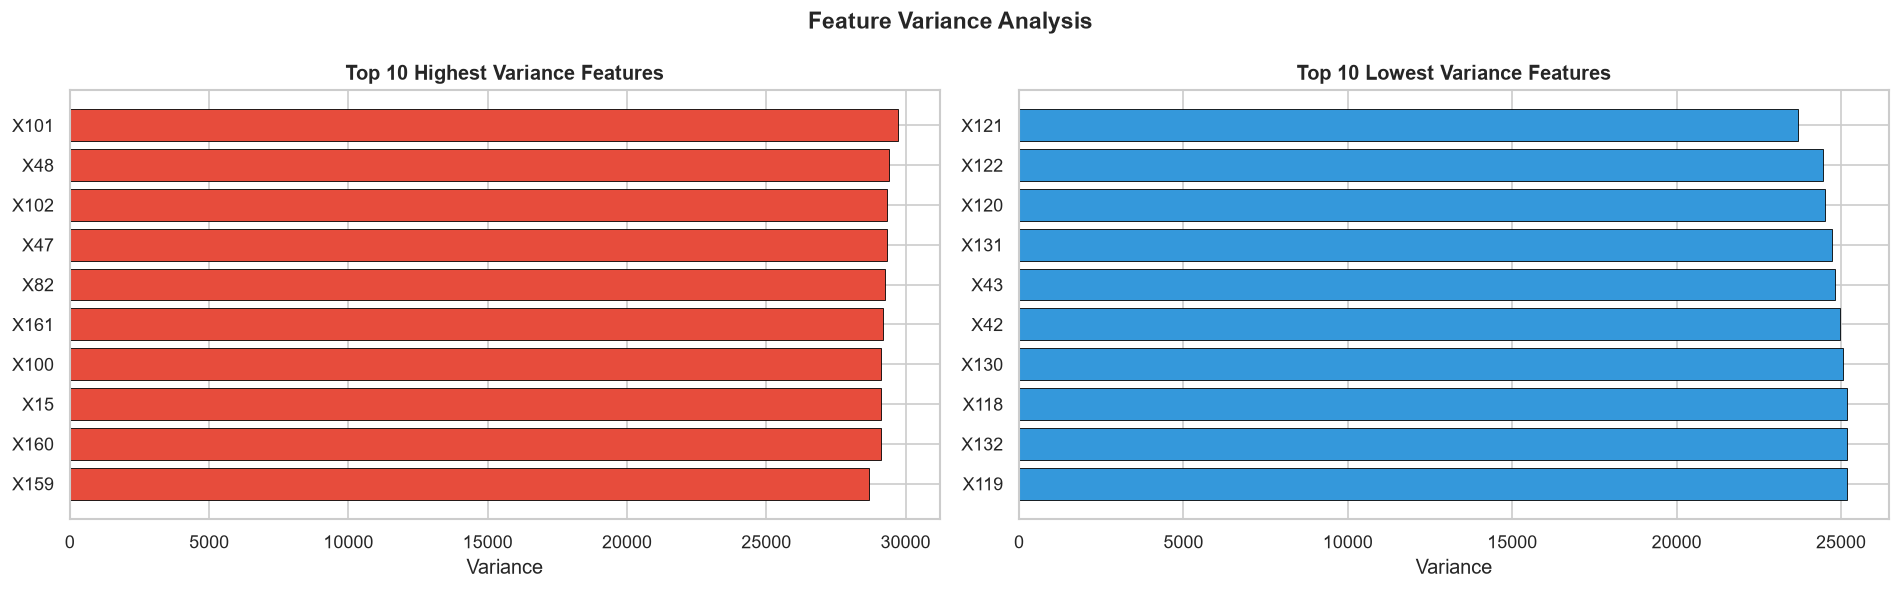

Mean variance across all features: 27087.54
Max variance: 29735.51 (X101)
Min variance: 23679.48 (X121)


In [10]:
X = df[feature_cols]
variances = X.var()
top10 = variances.nlargest(10)
bot10 = variances.nsmallest(10)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].barh(top10.index[::-1], top10.values[::-1], color='#e74c3c', edgecolor='black', lw=0.5)
axes[0].set_title('Top 10 Highest Variance Features', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Variance')

axes[1].barh(bot10.index[::-1], bot10.values[::-1], color='#3498db', edgecolor='black', lw=0.5)
axes[1].set_title('Top 10 Lowest Variance Features', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Variance')

plt.suptitle('Feature Variance Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/eda_feature_variance.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Mean variance across all features: {variances.mean():.2f}')
print(f'Max variance: {variances.max():.2f} ({variances.idxmax()})')
print(f'Min variance: {variances.min():.2f} ({variances.idxmin()})')

## 8. Correlation Heatmap (First 20 Features)

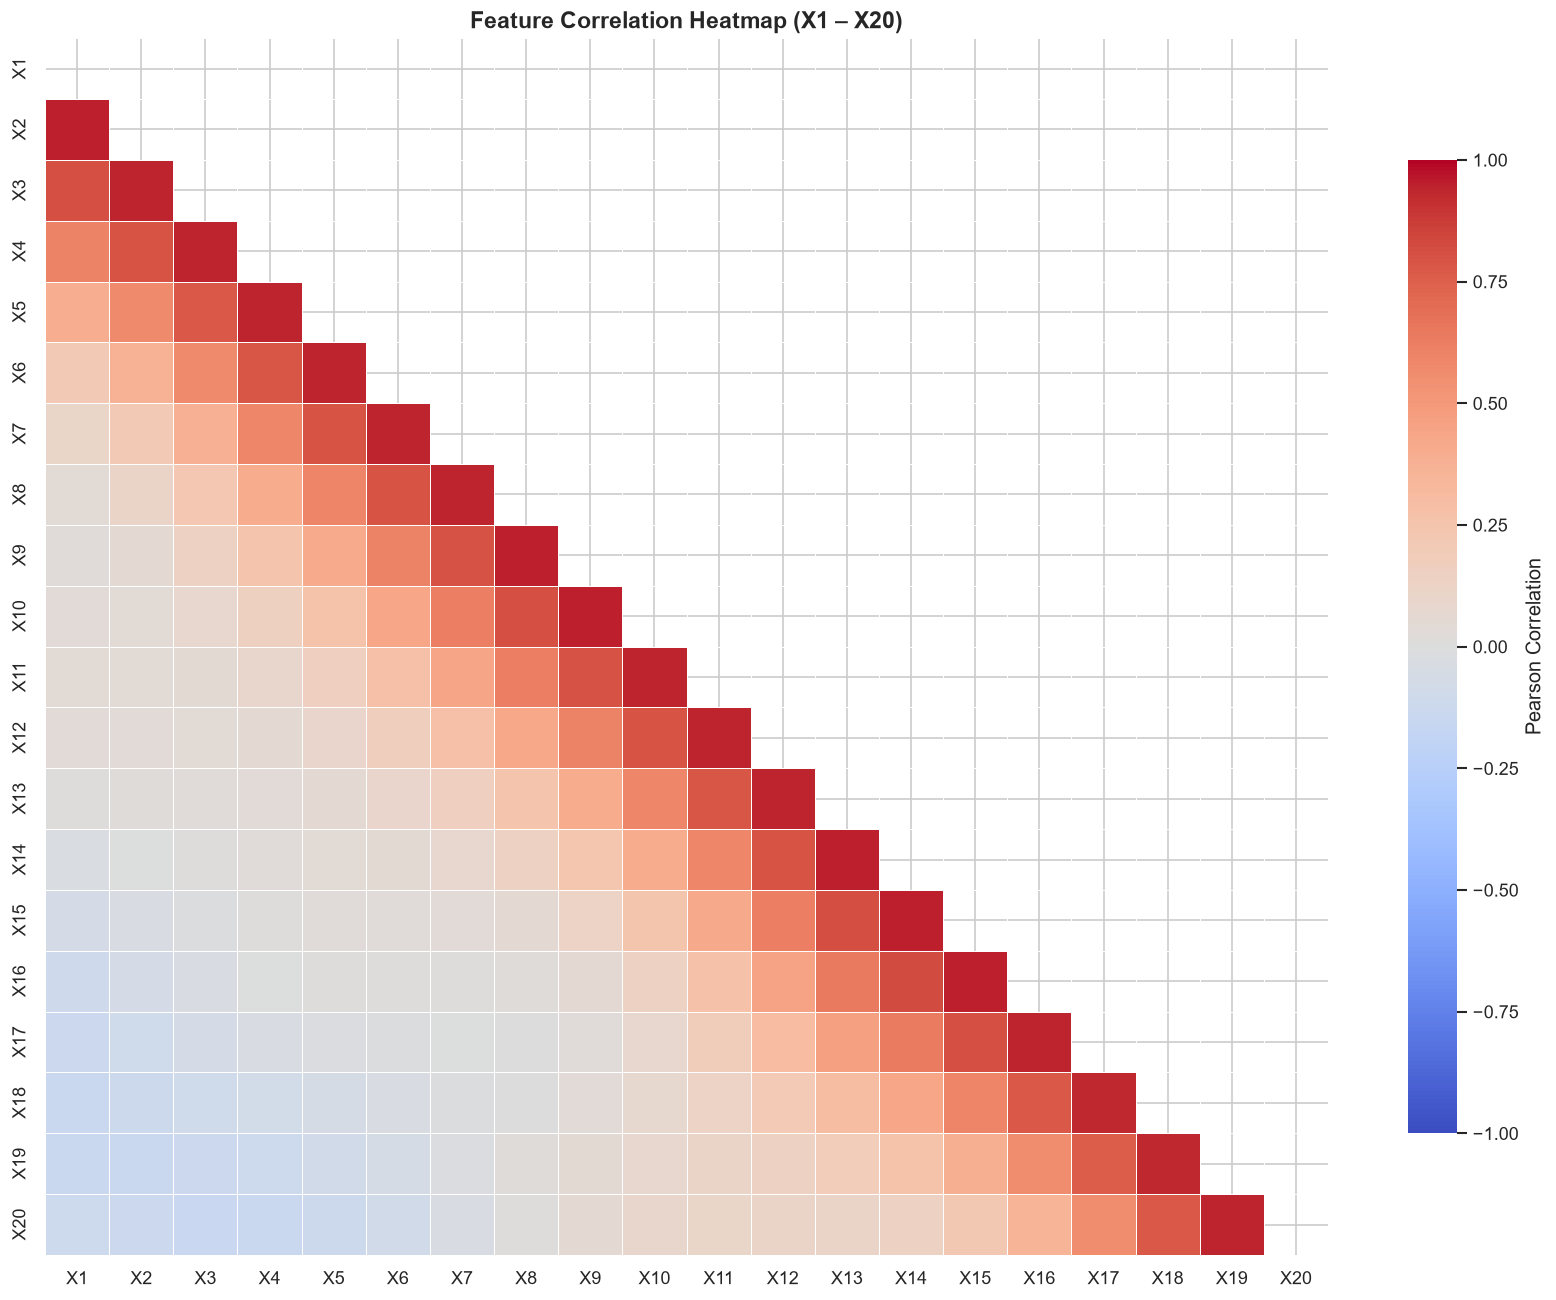

In [11]:
corr = df[feature_cols[:20]].corr()

fig, ax = plt.subplots(figsize=(14, 11))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=False, cmap='coolwarm', center=0,
            linewidths=0.3, ax=ax, vmin=-1, vmax=1,
            cbar_kws={'shrink': 0.8, 'label': 'Pearson Correlation'})
ax.set_title('Feature Correlation Heatmap (X1 – X20)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/eda_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. PCA — 2D Visualization

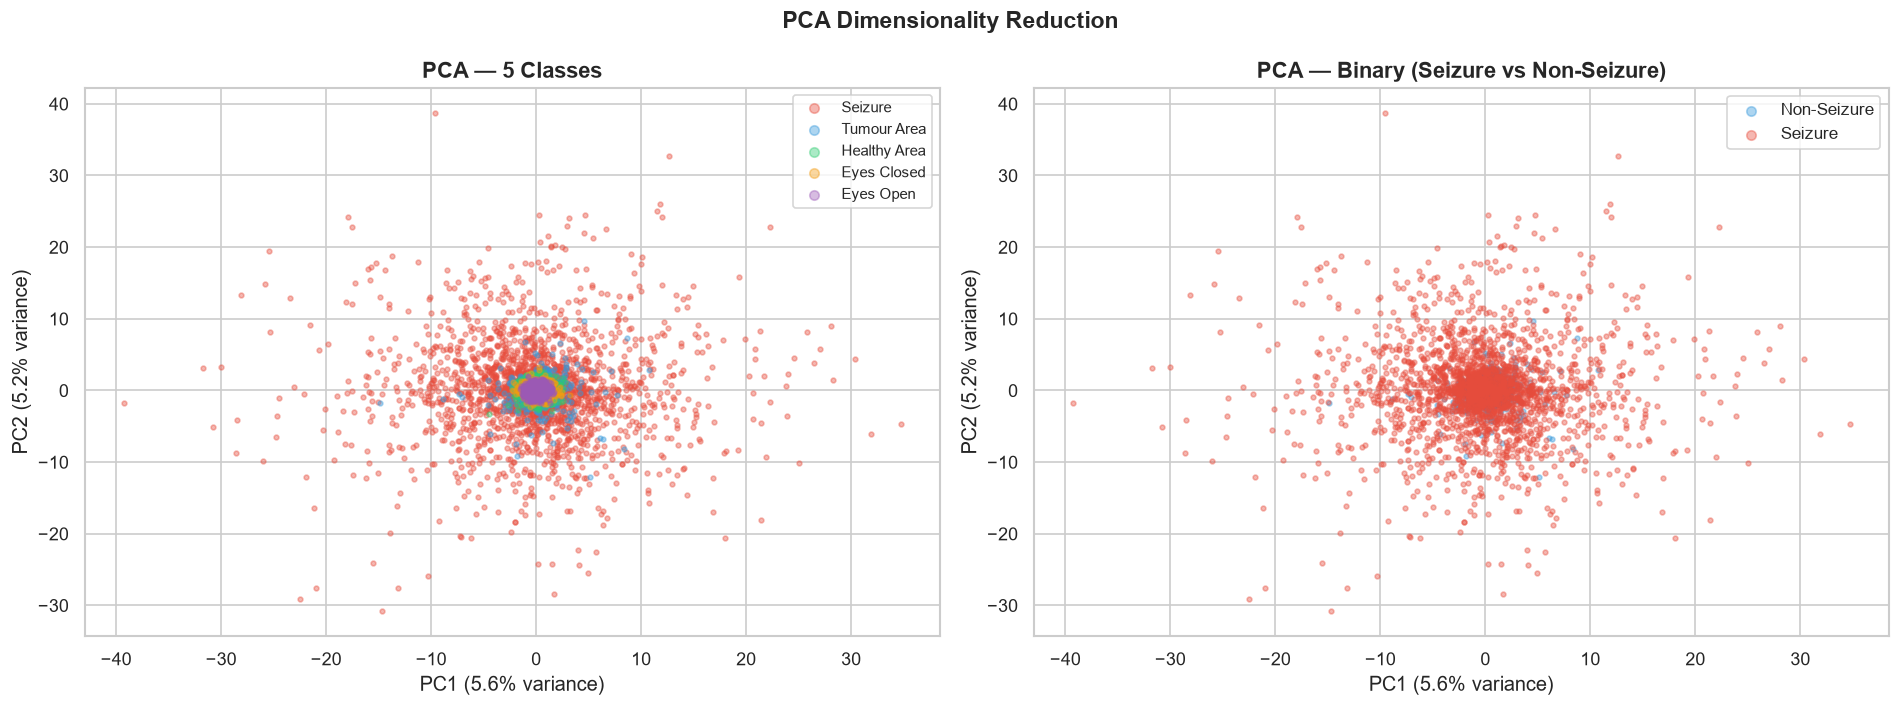

Explained variance — PC1: 5.61%, PC2: 5.24%
Total explained: 10.85%


In [12]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[feature_cols])

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 5-class PCA
for cls, color in zip(range(1, 6), CLASS_COLORS):
    mask = df['y'].values == cls
    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1], c=color,
                    label=CLASS_NAMES[cls], alpha=0.4, s=8)
axes[0].set_title('PCA — 5 Classes', fontsize=13, fontweight='bold')
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
axes[0].legend(markerscale=2, fontsize=9)

# Binary PCA
y_binary = (df['y'].values == 1).astype(int)
for label, color, name in zip([0, 1], ['#3498db', '#e74c3c'], ['Non-Seizure', 'Seizure']):
    mask = y_binary == label
    axes[1].scatter(X_pca[mask, 0], X_pca[mask, 1], c=color,
                    label=name, alpha=0.4, s=8)
axes[1].set_title('PCA — Binary (Seizure vs Non-Seizure)', fontsize=13, fontweight='bold')
axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
axes[1].legend(markerscale=2, fontsize=10)

plt.suptitle('PCA Dimensionality Reduction', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/eda_pca.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Explained variance — PC1: {pca.explained_variance_ratio_[0]*100:.2f}%, PC2: {pca.explained_variance_ratio_[1]*100:.2f}%')
print(f'Total explained: {sum(pca.explained_variance_ratio_)*100:.2f}%')

## 10. Average Signal Shape Per Class

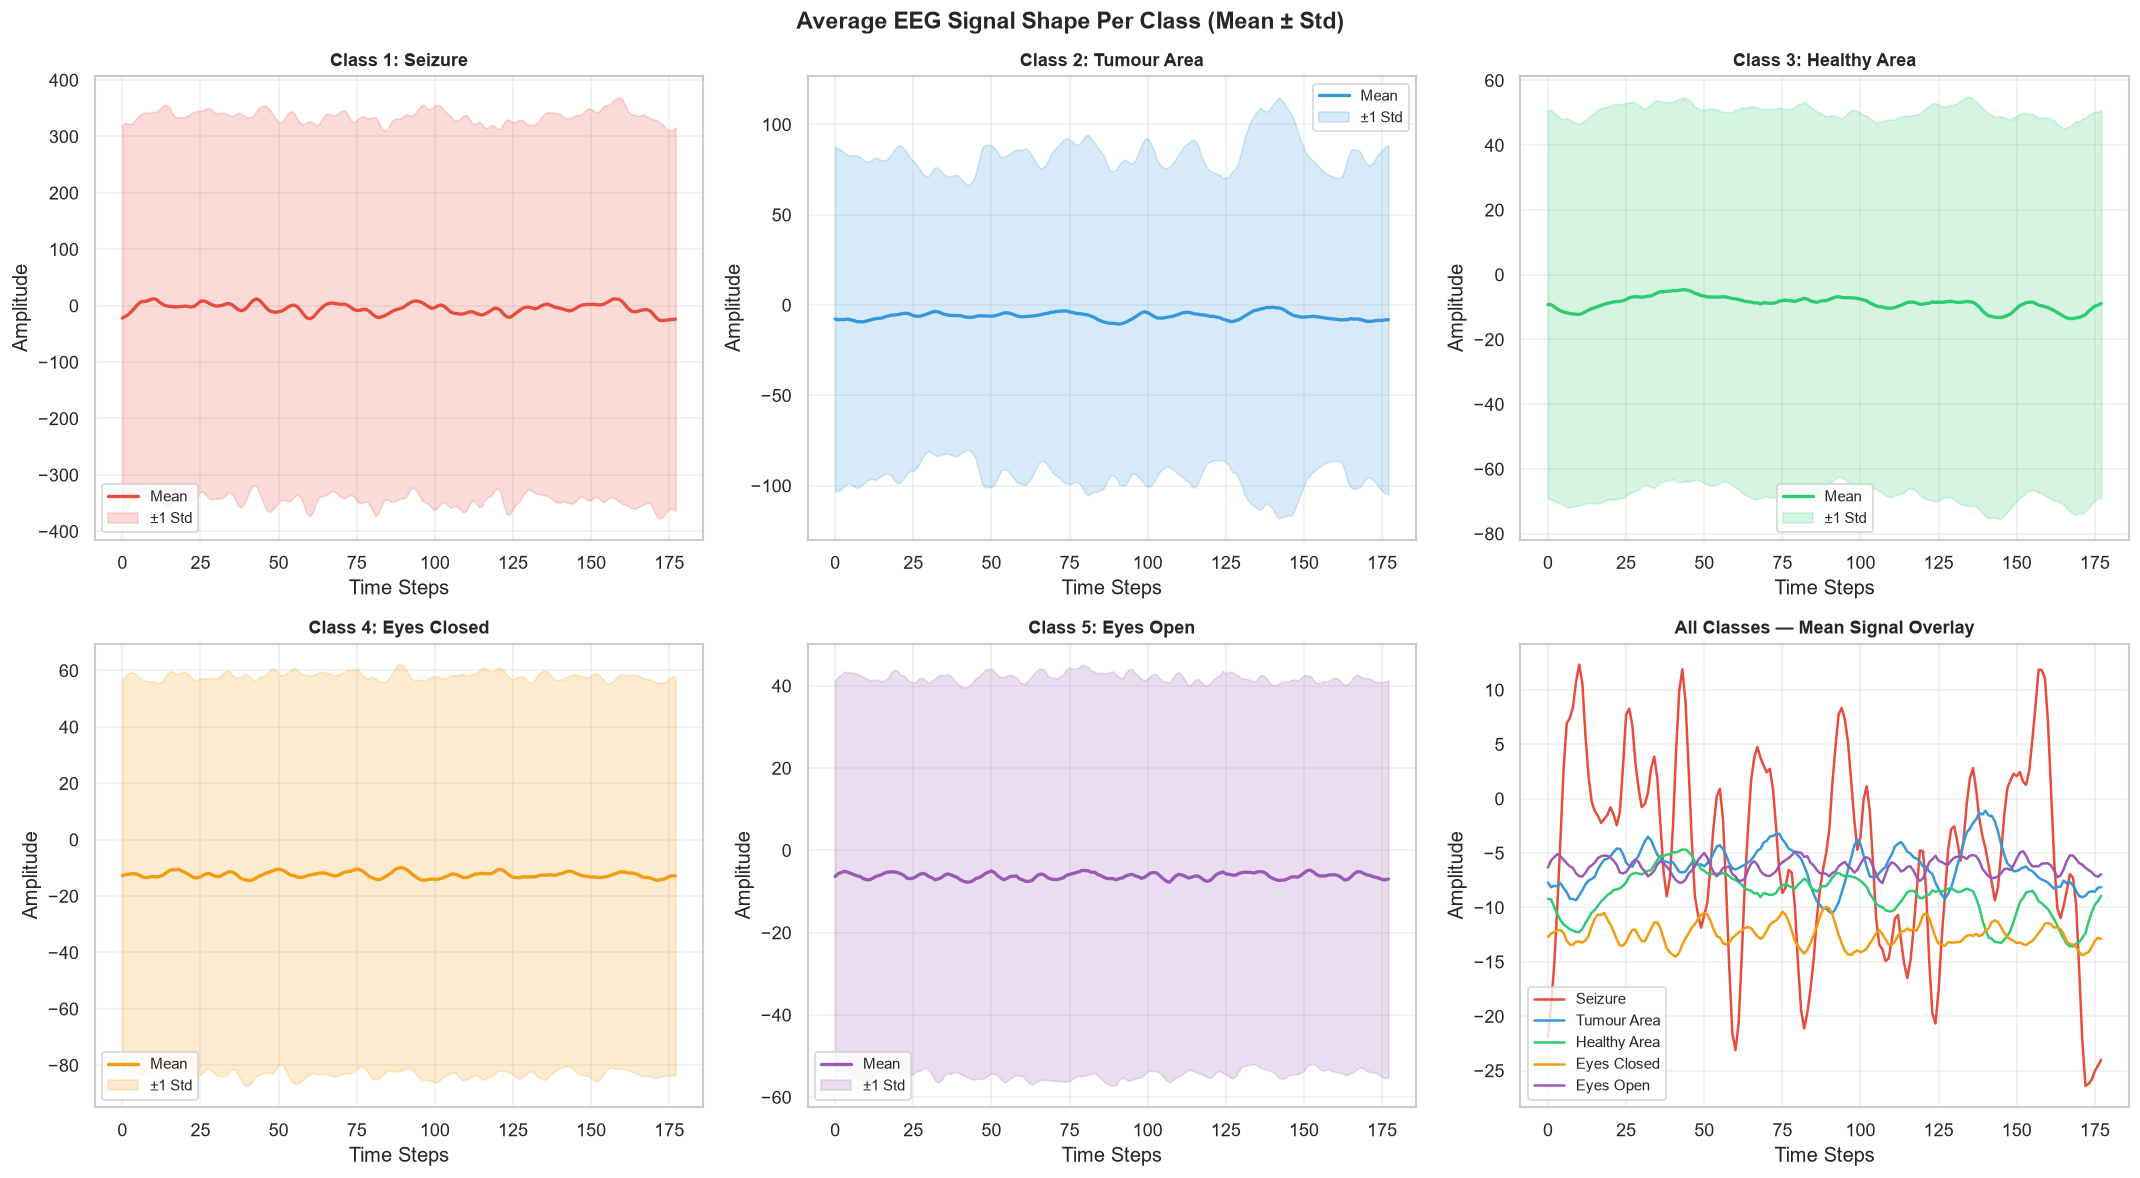

In [13]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, (cls, color) in enumerate(zip(range(1, 6), CLASS_COLORS)):
    subset = df[df['y'] == cls][feature_cols].values
    mean_signal = subset.mean(axis=0)
    std_signal  = subset.std(axis=0)
    t = np.arange(len(mean_signal))
    axes[i].plot(mean_signal, color=color, linewidth=2, label='Mean')
    axes[i].fill_between(t, mean_signal - std_signal, mean_signal + std_signal,
                          alpha=0.2, color=color, label='±1 Std')
    axes[i].set_title(f'Class {cls}: {CLASS_NAMES[cls]}', fontsize=11, fontweight='bold')
    axes[i].set_xlabel('Time Steps'); axes[i].set_ylabel('Amplitude')
    axes[i].legend(fontsize=9); axes[i].grid(alpha=0.3)

# Overlay all classes
for cls, color in zip(range(1, 6), CLASS_COLORS):
    mean_signal = df[df['y'] == cls][feature_cols].values.mean(axis=0)
    axes[5].plot(mean_signal, color=color, linewidth=1.5, label=CLASS_NAMES[cls])
axes[5].set_title('All Classes — Mean Signal Overlay', fontsize=11, fontweight='bold')
axes[5].set_xlabel('Time Steps'); axes[5].set_ylabel('Amplitude')
axes[5].legend(fontsize=9); axes[5].grid(alpha=0.3)

plt.suptitle('Average EEG Signal Shape Per Class (Mean ± Std)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/eda_avg_signal_per_class.png', dpi=150, bbox_inches='tight')
plt.show()

## 11. EDA Summary

In [14]:
print('='*55)
print('           EDA SUMMARY')
print('='*55)
print(f'  Total samples        : {len(df):,}')
print(f'  EEG features         : 178 time-steps')
print(f'  Classes              : 5 (perfectly balanced — 2,300 each)')
print(f'  Missing values       : None')
print(f'  Duplicates           : None')
print()
print('  Key Observations:')
print('  - Seizure signals (Class 1) show highest amplitude variance')
print('  - Non-seizure classes have more stable, lower amplitude signals')
print('  - PCA shows partial separation between seizure and non-seizure')
print('  - Dataset is perfectly balanced — no class weighting needed')
print('  - Binary task: Class 1 (seizure) vs Classes 2-5 (non-seizure)')
print('='*55)

           EDA SUMMARY
  Total samples        : 11,500
  EEG features         : 178 time-steps
  Classes              : 5 (perfectly balanced — 2,300 each)
  Missing values       : None
  Duplicates           : None

  Key Observations:
  - Seizure signals (Class 1) show highest amplitude variance
  - Non-seizure classes have more stable, lower amplitude signals
  - PCA shows partial separation between seizure and non-seizure
  - Dataset is perfectly balanced — no class weighting needed
  - Binary task: Class 1 (seizure) vs Classes 2-5 (non-seizure)
